In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# lkprf aperture tutorial

## Author
Rebekah Hounsell- TESS Science Support Center

## Tutorial Goals

This tutorial is a follow on from the lkprf TPF example tutorial. It demostrates how a user can calculate an aperture for an object of interest using knowledge of its PRF. 

There are three kinds of aperture that we will implement:

- Simple: This computes that aperture that covers the total light of the targets PRF. This is a very simple aperture which should only be used for bright isolated stare. The user determines the level of target flux to be included within the aperture using a completeness metric.
- Strict: This aperture is calculated using a measurement of the target flux / flux from all other contaminating sources. In this method the PRF is computed for the target and for other contaminating stars within the surronding region. The cumulative signal to noise is then calculated for the target and the local minima derived. This is then used to compute the size of the aperture mask.
- Balanced: This aperture is calculated based on the level of crowding acceptable to the user and the level of flux to be excluded. It has two input parameters, the flux fraction and the crowding fraction.

# Why is it important to select your aperture carefully?

When a planet transits its host star, it blocks a small fraction of the star's light. The observed dip in brightness, or transit depth, is used to determine the planet's size. However, if other stars are included in the aperture, the measured light comes from multiple sources and as such the measured transit depth inaccurate or "diluted". 

This dilution can be calculated via the following equation:

D<sub>i</sub> = F<sub>target</sub> / [F<sub>target</sub> + F<sub>contamination</sub>] 

Where a dilution factor of 1 implies no contaminating sources and less than one indicates contamination.

The dilution factor of a given aperture is returned with each `get_aperture` call.

An example of all three apertures and their calculated dilution factors are shown below, first for a bright isolated source, AU Mic, and then a faint crowded source TIC 120916706.

## Downloading Relevant Packages

In this notebook we will utilize basic packages such as numpy and matplotlib, and more advanced astronomy packages such as astropy, lightkurve, lksearch, and of course lkprf.

In [2]:
import numpy as np

import matplotlib.pyplot as plt

import lkprf
import lkprf.aperture as aper
import lksearch
from lksearch.catalogsearch import query_region

import lightkurve as lk

from astropy.wcs import WCS
from astropy.io import fits
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, Angle, Distance
from astroquery.vizier import Vizier
from astropy.table import Table, vstack

from typing import Union

import pandas as pd

### Defining a simple function

Much of this tutorial depends on deriving fundamental information from the header of the DataCube. This includes WCS infomration which will be used to convert object R.A and Dec values into x, y pixel positions such that a PRF model can be created. To enable this we have defined the following `get_surronding_objects` function.

In [3]:
def get_surronding_objects(tpf_file: pd.DataFrame,
                           catalog: str = 'tic', 
                           pixel_size = float,
                           radius: float = None,
                           output_epoch: Time = Time.now(),
                           max_results: int = 15):


    #Read in the DataCube file
    tess_hdulist = fits.open(tpf_file['Local Path'].values[0])
    
    #Get the WCS information
    wcs = WCS(tess_hdulist[2].header)

    #Get the x, y origin pixel values 
    origin_row =  tess_hdulist[1].header['2CRV4P'] 
    origin_col =  tess_hdulist[1].header['1CRV4P']
    
    #Get the shape of the tpf
    shape = tess_hdulist[1].data['FLUX'].shape[1:]
    
    #Get the ra and dec of the target
    ra = tess_hdulist[0].header['RA_OBJ'] 
    dec = tess_hdulist[0].header['DEC_OBJ'] 

    radius = (np.round(max(shape)/2) -1) * pixel_size *u.arcsec

    #Allowed catalogs
    allowed_catalogs = ['tic','kic','epic','gaiadr3']

    if catalog in allowed_catalogs:
    
        surronding_objects = query_region(SkyCoord(ra=ra, dec=dec, unit='deg'), output_epoch=output_epoch, catalog=catalog, radius=radius, max_results=max_results)

    else: 
        print("Allowed catalogs are 'tic','kic','epic','gaiadr3'")
        
    df_cleaned = surronding_objects.dropna(subset=['RA']).reset_index(drop=True)
    
    TESS_mags = df_cleaned['TESSmag'].values
    surronding_objects_ra = df_cleaned['RA'].values
    surronding_objects_dec = df_cleaned['Dec'].values
    
    column, row = wcs.world_to_pixel(SkyCoord(surronding_objects_ra,surronding_objects_dec, unit="deg"))
    
    target_col = column + origin_col 
    target_row = row + origin_row
    
    target_list = list(zip(target_row, target_col))

    return df_cleaned, TESS_mags, target_list, origin_row, origin_col
    

## Step 1: Get a the TPF
We will start by getting the Target Pixel File for a relatively isolated (low contamination) star, AU Mic. We limit the search using pipeline='SPOC', which restricts the search results to files produced by the mission pipeline. 

In [4]:
tpf_bright_search= lksearch.TESSSearch('Au Mic', pipeline='SPOC').cubedata
tpf_bright_search

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,441420236,SPOC,TESS,1,120.0,0.0,2018,Target pixel files
1,441420236,SPOC,TESS,27,20.0,0.0,2020,Target pixel files
2,441420236,SPOC,TESS,27,120.0,0.0,2020,Target pixel files
3,441420236,SPOC,TESS,95,20.0,0.0,2025,Target pixel files
4,441420236,SPOC,TESS,95,120.0,0.0,2025,Target pixel files


The search result contains a table showing all of the observations of the target for which SPOC data is available to download. The exptime column indicates the observing cadence by TESS. 

As we know from the previous tutorials the TPF will be different for this target for every observing sector, as the target will fall on different pixels and different camera and CCDs. Let's just pick a single sector to model. In the download command below, we specify the 1st element of the table, corresponding to the 20-second cadence TPF from sector 27.

In [5]:
tpf_bright = tpf_bright_search[1].download()
tpf_bright

,Local Path,Status,Message,URL
0,/Users/rhounsel/.lksearch/cache/mastDownload/T...,COMPLETE,None,None


We now have our dataframe containing the local file path it is downloaded to.  However, it does not read it in to a lightkurve object. We will read it in using the fits file handling package in astropy. If you need a refresher on fits file handling, you can see this [astropy tutorial](https://learn.astropy.org/tutorials/FITS-images.html). 

In [6]:
tess_hdulist = fits.open(tpf_bright['Local Path'].values[0])

## Step 2: Initializing a PRF model

Now that we have our file, we can set up our PRF model. 
To initiate a PRF object, we need to know which camera and CCD (TESS) or channel (Kepler) the target is on. We also can optionally provide the observing Sector for TESS. This is because two sets of PRF engineering models were produced for TESS. The first models were made during commissioning and are used for the early Sectors (Sectors 1-3). The commissioning observations were re-run after Sector 3, and these files can be used for subsequent TESS sectors. If the sector is not specified, the models produced for Sectors 4 onwards are used.

In [7]:
camera = tess_hdulist[0].header['CAMERA']
ccd = tess_hdulist[0].header['CCD']
sector = tess_hdulist[0].header['SECTOR'] 

shape = tess_hdulist[1].data['FLUX'].shape[1:]

# initialize the PRF object
prf_initial = lkprf.TESSPRF(camera=camera, ccd=ccd, sector=sector) 

## Step 3: Searching for objects in the surronding region

Now we want to assess what other objects might be in the surronding field. We can do this using the `get_surronding_objects` function defined above. This uses lksearch and some information from the header of our object, including it's WCS. We specify the number of targets to collect information for via the max_results input, we can also select the catalog we wish to search. 

In [8]:
object_table, TESS_mags, target_list, origin_row, origin_col  = get_surronding_objects(tpf_file = tpf_bright, catalog = 'tic', pixel_size = 21, output_epoch = Time.now(), max_results = 15)

This function has provided us with a list of objects within our region of interest, an array of TESS magnitudes for these objects, the x, y postion of the objects within the TPF, and the origin_row, origin_col for our TPF. We can view each as follows:

In [9]:
object_table

,ID,RA,Dec,Separation,Relative_Flux,pmRA,pmDE,TESSmag,Mass,Rad,Teff,logg
0,TIC 441420236,311.292080,-31.343480,0.000000,1.000000,281.424,-359.895,6.755000,0.662,0.698,NaN,4.5713
1,TIC 441420238,311.298135,-31.341866,19.504435,0.000200,7.181,-7.003,16.004999,0.850,0.886,5070.0,4.4727
2,TIC 441420240,311.284206,-31.344384,24.426406,0.000240,-3.239,-0.238,15.804000,0.650,0.681,3945.0,4.5842
3,TIC 441420232,311.295374,-31.334049,35.431021,0.000172,18.273,-14.821,16.167000,0.650,0.729,4133.0,4.5258
4,TIC 441420230,311.294068,-31.331439,43.777739,0.001037,11.049,-11.270,14.216000,1.040,1.123,5799.0,4.3544
...,...,...,...,...,...,...,...,...,...,...,...,...
8,TIC 1992412623,311.291374,-31.363607,72.488686,0.004238,-15.717,-18.767,12.687000,1.100,1.167,5980.0,4.3452
9,TIC 441420254,311.291696,-31.364920,77.193621,0.002004,-15.638,-18.905,13.500000,0.980,0.857,5571.0,4.5634
10,TIC 441420231,311.267326,-31.331477,87.525774,0.000073,13.025,-17.765,17.101999,0.514,0.516,3479.0,4.7232
11,TIC 441420225,311.269880,-31.326496,91.643221,0.000168,14.283,-0.974,16.191999,0.359,0.372,3498.0,4.8532


In [10]:
TESS_mags

array([ 6.755, 16.005, 15.804, 16.167, 14.216, 15.663, 14.966, 17.405,
       12.687, 13.5  , 17.102, 16.192, 16.322], dtype=float32)

In [11]:
target_list

[(1246.966007448939, 475.4225154658521),
 (1246.9680947225622, 474.4484169248344),
 (1246.7628613580305, 476.61839653286455),
 (1245.532001568138, 474.3867213885503),
 (1245.035240101073, 474.42178309291944),
 (1244.410348894742, 475.6294437558784),
 (1244.1289487478136, 476.1637804374784),
 (1244.7486741508628, 477.64092499434673),
 (1250.3111651478607, 476.71545753610866),
 (1250.5460864032154, 476.7463262999267),
 (1243.8368527564137, 478.3048298097157),
 (1243.1160512600845, 477.6397119679501),
 (1241.9432638656988, 475.07282519260525)]

In [12]:
origin_row, origin_col

(1240, 470)

## Step 4: Creating the 3D PRF model

We can now use the TESS magnitudes and x,y postions obtained above to construct our 3D PRF model data cube.

In [13]:
prf_mod = prf_initial.evaluate(targets=target_list,origin=(origin_row,origin_col),shape=shape)

We now have a model PRF's for our object and 14 other objects in the field that can be contaminating our source. Lets plot the target, and its PRF model. Red crosses mark the postion of all targets within the field.

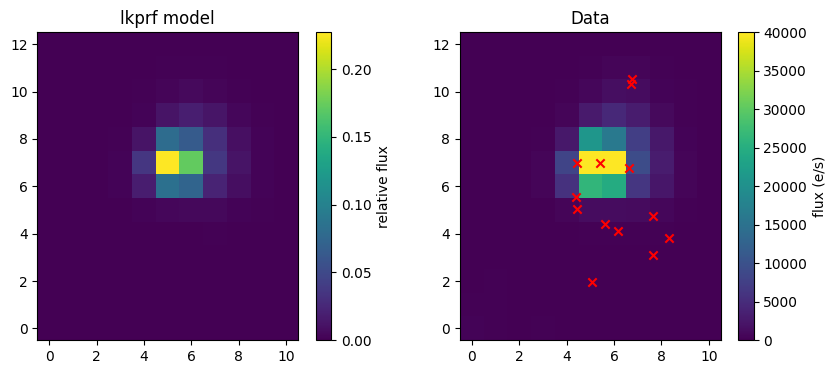

In [14]:
fig,axs = plt.subplots(1,2,figsize=(10,4))

model = axs[0].imshow(prf_mod[0,:,:], origin='lower')
axs[0].set_title('lkprf model')
fig.colorbar(model, ax = axs[0], label='relative flux')

# Plot the real data. We randomly select the 100th observation from the TPF data cube
data = axs[1].imshow(tess_hdulist[1].data['FLUX'][100,:,:], vmin=0, vmax=40000, origin='lower')
axs[1].set_title('Data')
for a in range(len(target_list)):
    axs[1].scatter(target_list[a][1]-origin_col, target_list[a][0]-origin_row, color="red", marker="x")
fig.colorbar(data, ax = axs[1], label = 'flux (e/s)')

plt.show()


## Step 5: Creating the apertures and calculating the dilution factor

Now lets generate the three possible apertures for our object using the `get_aperture` function and see what is selected. 

In [15]:
simple_ap, di_simple = prf_initial.get_aperture(aperture_type="simple", completeness=0.99, tess_mag = TESS_mags)
print("Dilution Factor:", di_simple)

Dilution Factor: 0.9930311782891152


In [16]:
strict_ap, di_strict = prf_initial.get_aperture(aperture_type="strict", tess_mag = TESS_mags)
print("Dilution Factor:", di_strict)

Dilution Factor: 0.9994431185627324


In [17]:
balanced_ap, di_balanced = prf_initial.get_aperture(aperture_type="balanced", crowding_metric = 0.8, fluxfrac_metric = 0.9,tess_mag = TESS_mags)
print("Dilution Factor:", di_balanced)

Dilution Factor: 0.9986946254369692


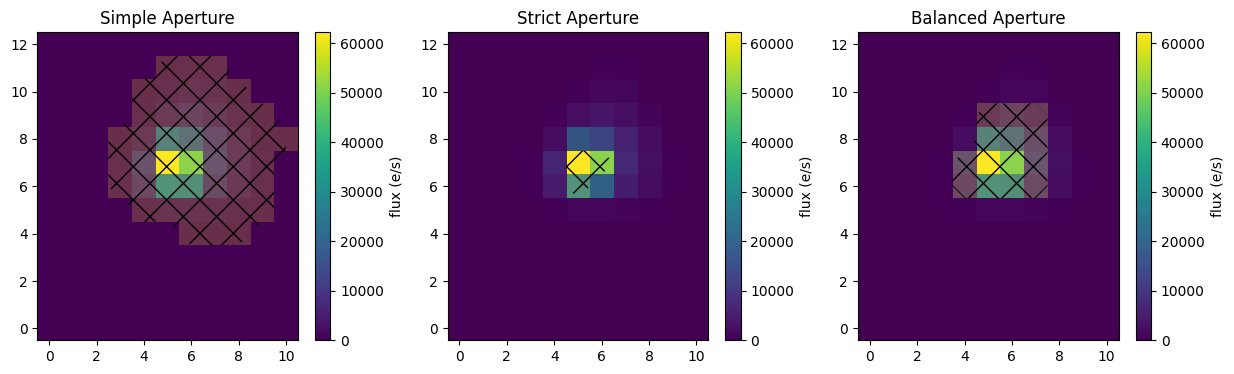

In [18]:
fig,axs = plt.subplots(1,3,figsize=(15,4))

data = axs[0].imshow(tess_hdulist[1].data['FLUX'][100,:,:],  origin='lower')
axs[0].imshow(simple_ap, alpha=0.2, origin='lower')
axs[0].contourf(
    simple_ap, 
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=['', 'x'],  # First for False, second for True
    colors='none',      # Use 'none' for colors to ensure transparency
    extend='both'       # This is important for handling out-of-range values
)
axs[0].set_title('Simple Aperture')
fig.colorbar(data, ax = axs[0], label = 'flux (e/s)')

data = axs[1].imshow(tess_hdulist[1].data['FLUX'][100,:,:],  origin='lower')
axs[1].imshow(strict_ap, alpha=0.2, origin='lower')
axs[1].contourf(
    strict_ap, 
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=['', 'x'],  # First for False, second for True
    colors='none',      # Use 'none' for colors to ensure transparency
    extend='both'       # This is important for handling out-of-range values
)
axs[1].set_title('Strict Aperture')
fig.colorbar(data, ax = axs[1], label = 'flux (e/s)')

data = axs[2].imshow(tess_hdulist[1].data['FLUX'][100,:,:],  origin='lower')
axs[2].imshow(balanced_ap, alpha=0.2,origin='lower')
axs[2].contourf(
    balanced_ap, 
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=['', 'x'],  # First for False, second for True
    colors='none',      # Use 'none' for colors to ensure transparency
    extend='both'       # This is important for handling out-of-range values
)
axs[2].set_title('Balanced Aperture')
fig.colorbar(data, ax = axs[2], label = 'flux (e/s)')

plt.show()

As we can see the simple aperture with 99% completeness is quite large, the strict aperture is quite small and will contain the maximum amount of flux from our target with the lest amount of contamination, as indicated by the dilution factor. The final balanced aperture tries to get 90% of the target flux while only allowing 20% contamination from surronding stars. 

## Step 6: Testing on a crowded object

Now lets repeat the experiment with a much fainter object, TIC 120916706.

In [30]:
tpf_faint_search = lksearch.TESSSearch("TIC 120916706", pipeline='SPOC').cubedata
tpf_faint_search

,target_name,pipeline,mission,sector,exptime,distance,year,description
0,120916706,SPOC,TESS,3,120.0,0.0,2018,Target pixel files
1,120916706,SPOC,TESS,30,120.0,0.0,2020,Target pixel files


In [31]:
tpf_faint = tpf_faint_search[0].download()

In [32]:
tess_hdulist_faint = fits.open(tpf_faint['Local Path'].values[0])

Let's plot this up and see what the target and its surronding region looks like.

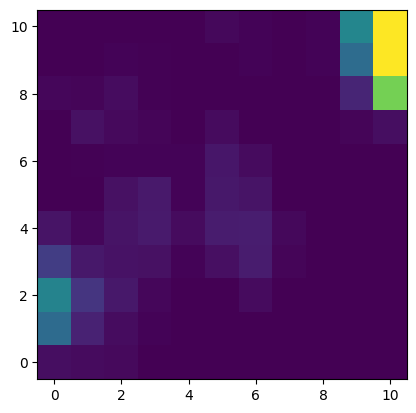

In [33]:
plt.imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:], vmin=5, vmax=200, origin='lower')

We can also use lightkurves `interact_sky()` funcation to examine the region surronding our object and gain some insight into the objects surronding it

In [34]:
lk.search_targetpixelfile("TIC 120916706")[0].download().interact_sky()

/Users/rhounsel/miniforge3/lib/python3.12/site-packages/lightkurve/interact.py:559: LightkurveWarning: interact_sky() - cannot obtain nearby TICs. Skip it. The error: 'GAIA DR2'
  warnings.warn(


In the plot above our object is in the center of the field and is very faint and surronded by lots of other faint and bright objects.  Using `interact` we can observe how the lightcurve of our target changes with the aperture selected. 

In [35]:
lk.search_targetpixelfile("TIC 120916706")[0].download().interact()

To calculate an aperture we must take the surronding objects into accont and be very selective about what pixels we include in our aperture mask. To do this we first gather information about the location of our target, and the surronding objects.  

In [36]:
camera_faint = tess_hdulist_faint[0].header['CAMERA']
ccd_faint = tess_hdulist_faint[0].header['CCD']
sector_faint = tess_hdulist_faint[0].header['SECTOR'] 

shape_faint = tess_hdulist_faint[1].data['FLUX'].shape[1:]

# initialize the PRF object
prf_initial_faint = lkprf.TESSPRF(camera=camera_faint, ccd=ccd_faint, sector=sector_faint) 

Now examine objects within the surronding region.

In [37]:
object_table_faint, TESS_mags_faint, target_list_faint, origin_row_faint, origin_col_faint  = get_surronding_objects(tpf_file = tpf_faint, catalog = 'tic', pixel_size = 21, output_epoch = Time.now(), max_results = 25)

In [38]:
object_table_faint

,ID,RA,Dec,Separation,Relative_Flux,pmRA,pmDE,TESSmag,Mass,Rad,Teff,logg
0,TIC 120916706,37.108373,-25.097300,0.000000,1.000000,30.333,10.142,15.620000,0.436,0.440,3423.0,4.7907
1,TIC 120916709,37.097679,-25.087633,49.259772,1.221237,-0.417,8.098,15.403000,0.760,0.652,4721.0,4.6905
2,TIC 120916710,37.114387,-25.083546,53.254410,1.088429,8.141,-1.314,15.528000,1.000,0.979,5625.0,4.4562
3,TIC 120916705,37.130260,-25.101787,73.158735,0.281838,6.393,-5.949,16.995001,0.650,0.961,4130.0,4.2859
4,TIC 120916707,37.135359,-25.091443,90.473146,0.976338,62.346,-1.405,15.646000,1.030,0.577,5741.0,4.9287
5,TIC 120916704,37.124030,-25.119028,93.400984,0.561823,5.918,-5.036,16.246000,0.720,0.823,4567.0,4.4645


There are lots of similarly bright objects in this region, we must model these.

In [39]:
prf_mod_faint = prf_initial_faint.evaluate(targets=target_list_faint,origin=(origin_row_faint,origin_col_faint),shape=shape_faint)

We can plot our model vz. our data and we can examine the relative flux scale to see how faint this object is with respect to other stars in the field.

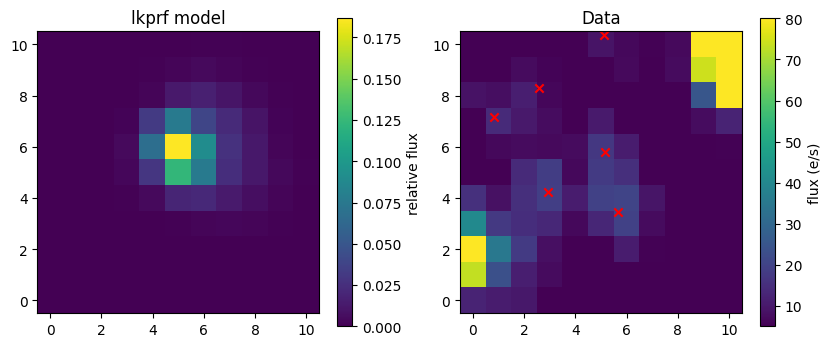

In [40]:
fig,axs = plt.subplots(1,2,figsize=(10,4))

model = axs[0].imshow(prf_mod_faint[0,:,:], origin='lower')
axs[0].set_title('lkprf model')
fig.colorbar(model, ax = axs[0], label='relative flux')

# Plot the real data. We randomly select the 100th observation from the TPF data cube
data = axs[1].imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:], vmin=5, vmax=80, origin='lower')
axs[1].set_title('Data')
for a in range(len(target_list_faint)):
    axs[1].scatter(target_list_faint[a][1]-origin_col_faint, target_list_faint[a][0]-origin_row_faint, color="red", marker="x")
fig.colorbar(data, ax = axs[1], label = 'flux (e/s)')

plt.show()

Now lets compute our apertures based on the PRF. 

In [47]:
simple_ap_faint, di_simple_faint = prf_initial_faint.get_aperture(aperture_type="simple", completeness=0.9,tess_mag = TESS_mags_faint)
print("Dilution Factor for Simple Aperture:", di_simple_faint)
strict_ap_faint, di_strict_faint = prf_initial_faint.get_aperture(aperture_type="strict", tess_mag = TESS_mags_faint)
print("Dilution Factor for Strict Aperture:", di_strict_faint)
balanced_ap_faint, di_balanced_faint = prf_initial_faint.get_aperture(aperture_type="balanced", crowding_metric = 0.8, fluxfrac_metric = 0.9,tess_mag = TESS_mags_faint)
print("Dilution Factor for Balanced Aperture:", di_balanced_faint)

Dilution Factor for Simple Aperture: 0.5250268375560881
Dilution Factor for Strict Aperture: 0.7488265347319966
Dilution Factor for Balanced Aperture: 0.8829742695902985


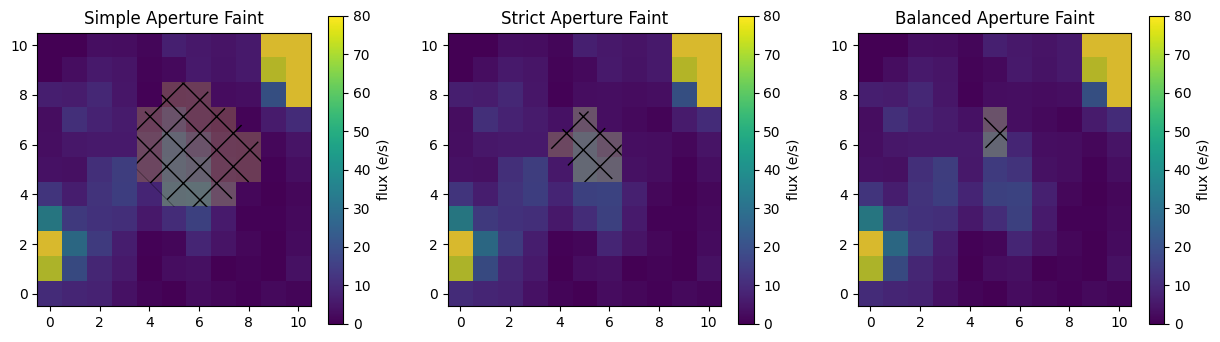

In [46]:
fig,axs = plt.subplots(1,3,figsize=(15,4))

data = axs[0].imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:],  origin='lower',vmin=0, vmax=80)
axs[0].contourf(
    simple_ap_faint, 
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=['', 'x'],  # First for False, second for True
    colors='none',      # Use 'none' for colors to ensure transparency
    extend='both'       # This is important for handling out-of-range values
)
axs[0].imshow(simple_ap_faint, alpha=0.2, origin='lower')
axs[0].set_title('Simple Aperture Faint')
fig.colorbar(data, ax = axs[0], label = 'flux (e/s)')

data = axs[1].imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:],  origin='lower',vmin=0, vmax=80)
axs[1].imshow(strict_ap_faint, alpha=0.2, origin='lower')
axs[1].contourf(
    strict_ap_faint, 
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=['', 'x'],  # First for False, second for True
    colors='none',      # Use 'none' for colors to ensure transparency
    extend='both'       # This is important for handling out-of-range values
)
axs[1].set_title('Strict Aperture Faint')
fig.colorbar(data, ax = axs[1], label = 'flux (e/s)')

data = axs[2].imshow(tess_hdulist_faint[1].data['FLUX'][100,:,:],  origin='lower',vmin=0, vmax=80)
axs[2].imshow(balanced_ap_faint, alpha=0.2, origin='lower')
axs[2].contourf(
    balanced_ap_faint, 
    levels=[0.5, 1.5],  # Contour levels to isolate the True values
    hatches=['', 'x'],  # First for False, second for True
    colors='none',      # Use 'none' for colors to ensure transparency
    extend='both'       # This is important for handling out-of-range values
)
axs[2].set_title('Balanced Aperture Faint')
fig.colorbar(data, ax = axs[2], label = 'flux (e/s)')

plt.show()

We can see here that the crowded aperture is probably the best one here as we want to reduce contamination while maximizing flux contained, this also indicated by it having the highest dilution factor. 